# **1. Perkenalan Dataset**


# Perkenalan Dataset

## Informasi Dataset

Dataset yang digunakan dalam eksperimen ini adalah **Store Item Demand Forecasting Dataset** yang diperoleh dari platform Kaggle.

**Sumber Dataset:**  
https://www.kaggle.com/datasets/dhrubangtalukdar/store-item-demand-forecasting-dataset

## Deskripsi Dataset


Dataset **Store Item Demand Forecasting** adalah dataset sintetis yang dibuat untuk merepresentasikan data penjualan ritel harian dari berbagai toko dan produk selama periode lima tahun, yaitu 2019–2023. Dataset ini dikembangkan sebagai sarana pendukung penelitian dan eksperimen yang berkaitan dengan **peramalan deret waktu (time series forecasting)**, **prediksi permintaan (demand forecasting)**, serta **analisis penjualan ritel**.

Data dalam dataset ini memiliki tingkat detail harian (**daily sales**) dan mencakup berbagai kombinasi toko serta produk. Setiap data dicatat pada level **toko-produk-hari (store-item-day)**, sehingga memungkinkan pengguna melakukan analisis yang lebih mendalam terhadap pola penjualan, tren permintaan, dan perilaku penjualan pada masing-masing produk di setiap toko.


## Karakteristik Dataset

Beberapa karakteristik utama dataset adalah sebagai berikut:

- Periode data: Januari 2019 – Desember 2023.
- Granularitas data: Harian (*daily sales*).
- Jumlah toko: 50 toko.
- Jumlah produk: 50 produk.
- Memuat informasi penjualan, harga produk, dan status promosi.
- Mengandung pola tren, musiman (*seasonality*), serta pengaruh promosi terhadap penjualan.

Dataset ini mensimulasikan kondisi penjualan ritel yang realistis dengan mempertimbangkan beberapa faktor, seperti permintaan dasar pada setiap toko dan produk, tren pertumbuhan penjualan jangka panjang, pola musiman mingguan dan tahunan, pengaruh promosi, serta variasi acak (*random noise*) yang umum ditemukan pada data dunia nyata. :contentReference[oaicite:0]{index=0}

## Deskripsi Atribut

Berikut merupakan atribut yang terdapat pada dataset:

| Atribut | Deskripsi |
|----------|----------|
| date | Tanggal observasi penjualan |
| store_id | Identitas unik toko |
| item_id | Identitas unik produk |
| sales | Jumlah produk yang terjual pada hari tersebut |
| price | Harga produk |
| promo | Status promosi (1 = promosi aktif, 0 = tidak ada promosi) |
| weekday | Hari dalam satu minggu (0–6) |
| month | Bulan pengamatan (1–12) |


In [42]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("dhrubangtalukdar/store-item-demand-forecasting-dataset")

print("Path dataset files:", path)

Using Colab cache for faster access to the 'store-item-demand-forecasting-dataset' dataset.
Path dataset files: /kaggle/input/store-item-demand-forecasting-dataset


# **2. Import Library**

Pada tahap ini, Anda perlu mengimpor beberapa pustaka (library) Python yang dibutuhkan untuk analisis data dan pembangunan model machine learning atau deep learning.

In [43]:
import sys
!{sys.executable} -m pip install mlflow

# Data manipulation
import pandas as pd
import numpy as np

# Visualisasi (EDA)
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler

# Model ML
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

# MLflow untuk kriteria 2
import mlflow
import mlflow.sklearn

# **3. Memuat Dataset**

Pada tahap ini, Anda perlu memuat dataset ke dalam notebook. Jika dataset dalam format CSV, Anda bisa menggunakan pustaka pandas untuk membacanya. Pastikan untuk mengecek beberapa baris awal dataset untuk memahami strukturnya dan memastikan data telah dimuat dengan benar.

Jika dataset berada di Google Drive, pastikan Anda menghubungkan Google Drive ke Colab terlebih dahulu. Setelah dataset berhasil dimuat, langkah berikutnya adalah memeriksa kesesuaian data dan siap untuk dianalisis lebih lanjut.

Jika dataset berupa unstructured data, silakan sesuaikan dengan format seperti kelas Machine Learning Pengembangan atau Machine Learning Terapan

**Import Library**

In [44]:
#Type your code here
import pandas as pd
import os

**Path Dataset**

In [45]:
# melihat isi folder
os.listdir(path)

['retail_sales.csv']

**Read Dataset**

In [46]:
file_path = path + "/retail_sales.csv"  # sesuaikan dengan nama file
df = pd.read_csv(file_path)

**Menampilkan Data Awal**

In [47]:
df.head()

,date,store_id,item_id,sales,price,promo,weekday,month
0,2019-01-01,store_1,item_1,41,21.30,0,1,1
1,2019-01-02,store_1,item_1,53,21.30,0,2,1
2,2019-01-03,store_1,item_1,39,21.30,0,3,1
3,2019-01-04,store_1,item_1,35,21.30,0,4,1
4,2019-01-05,store_1,item_1,51,17.04,1,5,1


**Info Dataset**

In [48]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4565000 entries, 0 to 4564999
Data columns (total 8 columns):
 #   Column    Dtype  
---  ------    -----  
 0   date      object 
 1   store_id  object 
 2   item_id   object 
 3   sales     int64  
 4   price     float64
 5   promo     int64  
 6   weekday   int64  
 7   month     int64  
dtypes: float64(1), int64(4), object(3)
memory usage: 278.6+ MB


**Ukuran Dataset**

In [49]:
df.shape

(4565000, 8)

# **4. Exploratory Data Analysis (EDA)**

Pada tahap ini, Anda akan melakukan **Exploratory Data Analysis (EDA)** untuk memahami karakteristik dataset.

Tujuan dari EDA adalah untuk memperoleh wawasan awal yang mendalam mengenai data dan menentukan langkah selanjutnya dalam analisis atau pemodelan.

In [50]:
#Type your code here
# =========================
# EXPLORATORY DATA ANALYSIS
# =========================

import matplotlib.pyplot as plt
import seaborn as sns

# setting style
sns.set(style="whitegrid")


**Cek Missing Values**

In [51]:
print("=== Missing Values ===")
print(df.isnull().sum())

=== Missing Values ===
date        0
store_id    0
item_id     0
sales       0
price       0
promo       0
weekday     0
month       0
dtype: int64


**Distribusi Target (Sales)**

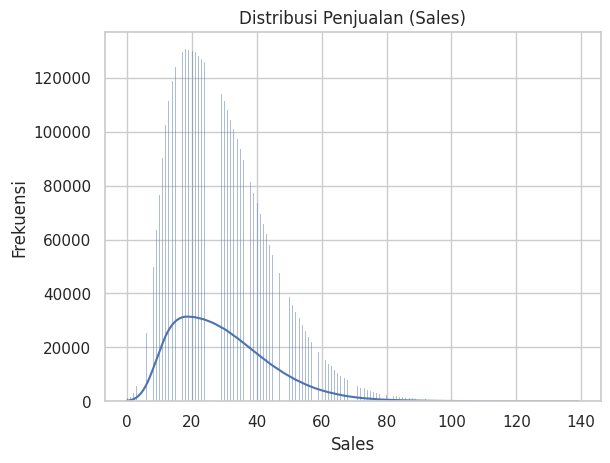

In [52]:
plt.figure()
sns.histplot(df['sales'], kde=True)
plt.title("Distribusi Penjualan (Sales)")
plt.xlabel("Sales")
plt.ylabel("Frekuensi")
plt.show()

**Tren Penjualan terhadap Waktu**

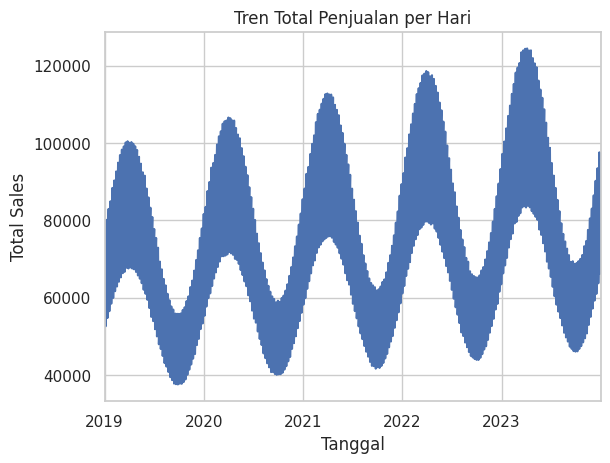

In [53]:
df['date'] = pd.to_datetime(df['date'])

sales_per_day = df.groupby('date')['sales'].sum()

plt.figure()
sales_per_day.plot()
plt.title("Tren Total Penjualan per Hari")
plt.xlabel("Tanggal")
plt.ylabel("Total Sales")
plt.show()

**Penjualan per Store**

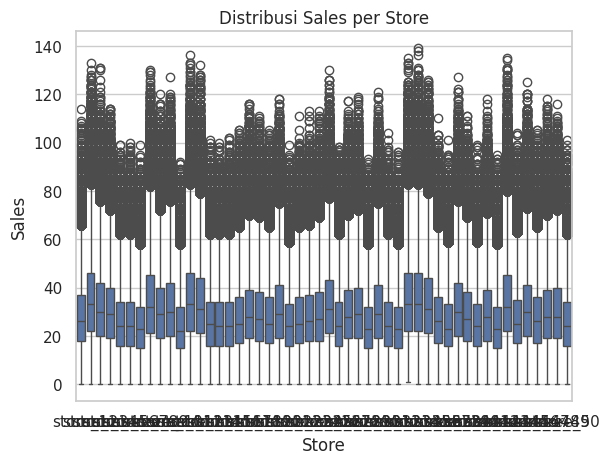

In [54]:
plt.figure()
sns.boxplot(x='store_id', y='sales', data=df)
plt.title("Distribusi Sales per Store")
plt.xlabel("Store")
plt.ylabel("Sales")
plt.show()

Penjualan per Item

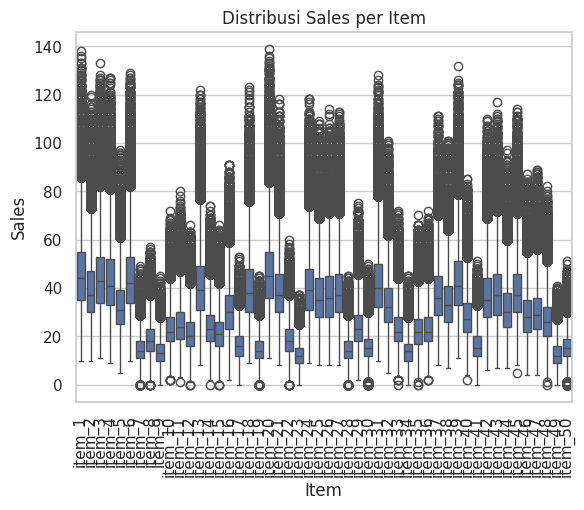

In [55]:
plt.figure()
sns.boxplot(x='item_id', y='sales', data=df)
plt.title("Distribusi Sales per Item")
plt.xlabel("Item")
plt.ylabel("Sales")
plt.xticks(rotation=90)
plt.show()

**Korelasi Antar Fitur**

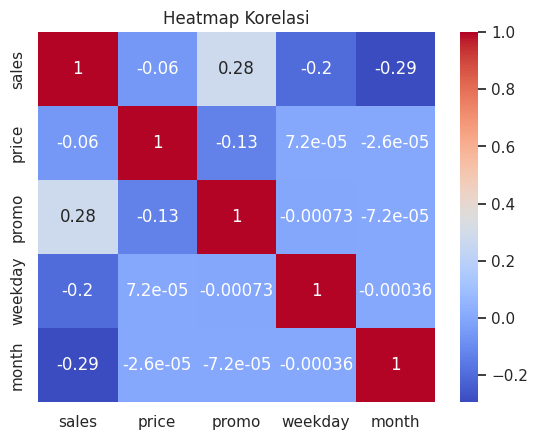

In [56]:
plt.figure()
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title("Heatmap Korelasi")
plt.show()

# **5. Data Preprocessing**

Pada tahap ini, data preprocessing adalah langkah penting untuk memastikan kualitas data sebelum digunakan dalam model machine learning.

Jika Anda menggunakan data teks, data mentah sering kali mengandung nilai kosong, duplikasi, atau rentang nilai yang tidak konsisten, yang dapat memengaruhi kinerja model. Oleh karena itu, proses ini bertujuan untuk membersihkan dan mempersiapkan data agar analisis berjalan optimal.

Berikut adalah tahapan-tahapan yang bisa dilakukan, tetapi **tidak terbatas** pada:
1. Menghapus atau Menangani Data Kosong (Missing Values)
2. Menghapus Data Duplikat
3. Normalisasi atau Standarisasi Fitur
4. Deteksi dan Penanganan Outlier
5. Encoding Data Kategorikal
6. Binning (Pengelompokan Data)

Cukup sesuaikan dengan karakteristik data yang kamu gunakan yah. Khususnya ketika kami menggunakan data tidak terstruktur.

In [57]:
# =========================
# DATA PREPROCESSING
# =========================

from sklearn.preprocessing import LabelEncoder

# copy dataset
df_clean = df.copy()

**Missing Values**

In [58]:
print("Missing Values Sebelum:")
print(df_clean.isnull().sum())

df_clean = df_clean.dropna()

print("\nMissing Values Setelah:")
print(df_clean.isnull().sum())

Missing Values Sebelum:
date        0
store_id    0
item_id     0
sales       0
price       0
promo       0
weekday     0
month       0
dtype: int64

Missing Values Setelah:
date        0
store_id    0
item_id     0
sales       0
price       0
promo       0
weekday     0
month       0
dtype: int64


**Duplicate Data**

In [59]:
print("\nShape sebelum duplikat:", df_clean.shape)

df_clean = df_clean.drop_duplicates()

print("Shape setelah duplikat:", df_clean.shape)


Shape sebelum duplikat: (4565000, 8)
Shape setelah duplikat: (4565000, 8)


**Feature Engineering (Date)**

In [60]:
df_clean['date'] = pd.to_datetime(df_clean['date'])

df_clean['year'] = df_clean['date'].dt.year
df_clean['month'] = df_clean['date'].dt.month
df_clean['day'] = df_clean['date'].dt.day
df_clean['dayofweek'] = df_clean['date'].dt.dayofweek

**Encoding Data Kategorikal**

le_store = LabelEncoder()
le_item = LabelEncoder()

df_clean['store'] = le_store.fit_transform(df_clean['store'])
df_clean['item'] = le_item.fit_transform(df_clean['item'])

**Outlier Handling (IQR)**

In [61]:
Q1 = df_clean['sales'].quantile(0.25)
Q3 = df_clean['sales'].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

df_clean = df_clean[(df_clean['sales'] >= lower) & (df_clean['sales'] <= upper)]

print("\nShape setelah outlier handling:", df_clean.shape)


Shape setelah outlier handling: (4490764, 11)


**Drop Kolom Tidak Diperlukan**

In [62]:
df_clean = df_clean.drop(columns=['date'])

**Dataset Final**

In [63]:
print("\n=== Preview Data Final ===")
print(df_clean.head())

print("\nShape akhir dataset:", df_clean.shape)


=== Preview Data Final ===
  store_id item_id  sales  price  promo  weekday  month  year  day  dayofweek
0  store_1  item_1     41  21.30      0        1      1  2019    1          1
1  store_1  item_1     53  21.30      0        2      1  2019    2          2
2  store_1  item_1     39  21.30      0        3      1  2019    3          3
3  store_1  item_1     35  21.30      0        4      1  2019    4          4
4  store_1  item_1     51  17.04      1        5      1  2019    5          5

Shape akhir dataset: (4490764, 10)


In [64]:
# simpan dataset hasil preprocessing
df_clean.to_csv("dataset_preprocessing.csv", index=False)

print("Dataset preprocessing berhasil disimpan!")

Dataset preprocessing berhasil disimpan!
